# 05. Lorenz-63 4D-Var (strong constraint)

이 노트북에서는 Lorenz-63 모델에 **strong-constraint 4D-Var** 를 적용한다.

3D-Var(02번)는 한 시각의 관측만 사용해 그 시각의 상태를 보정했다.
4D-Var는 **시간창(assimilation window) 전체의 관측**을 한꺼번에 사용해,
window 시작 시각의 상태 $\mathbf{x}_0$ 하나를 최적으로 추정한다.

모델이 완벽하다고 가정하므로(strong constraint), $\mathbf{x}_0$ 만 정해지면 window 전체 궤적이 결정된다.

이번 실습의 목표는 다음과 같다.

1. 4D-Var cost function과 adjoint gradient를 이해한다.
2. adjoint gradient가 유한차분 gradient와 일치하는지 확인한다.
3. `scipy.optimize`로 cost function을 최소화한다.
4. 분석된 초기조건이 truth에 가까워지는지, 그리고 window 이후 예측이 개선되는지 확인한다.

## 1. 라이브러리 불러오기

이번 실습에서는 이번에 작성한 `four_dvar` 모듈을 사용한다.
이 모듈의 gradient는 03번 TLM과 04번 adjoint에서 만든 `euler_adjoint_matrix`를 재사용한다.

In [11]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from lorenz_da.models.lorenz63 import (
    lorenz63_rhs,
    lorenz63_default_initial_condition,
)
from lorenz_da.numerics.euler import integrate_euler
from lorenz_da.observations.operator import identity_observation_operator
from lorenz_da.observations.synthetic import (
    make_observation_indices,
    generate_synthetic_observations,
)
from lorenz_da.assimilation.four_dvar import (
    four_dvar_cost,
    four_dvar_cost_and_grad,
)
from lorenz_da.utils.diagnostics import rmse_time_series, mean_rmse

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

In [12]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. 4D-Var cost function과 gradient

control variable은 window 시작 상태 $\mathbf{x}_0$ 이다.
cost function은 background 항과 observation 항의 합이다.

$$
J(\mathbf{x}_0) =
\frac{1}{2}(\mathbf{x}_0 - \mathbf{x}_0^b)^T B^{-1}(\mathbf{x}_0 - \mathbf{x}_0^b)
+ \frac{1}{2}\sum_{k}(H\mathbf{x}_k - \mathbf{y}_k)^T R^{-1}(H\mathbf{x}_k - \mathbf{y}_k)
$$

여기서 $\mathbf{x}_k$ 는 $\mathbf{x}_0$ 에서 출발한 forward 모델 궤적의 관측 시각 상태이다.

gradient는 adjoint model로 효율적으로 계산한다.

$$
\nabla J(\mathbf{x}_0) = B^{-1}(\mathbf{x}_0 - \mathbf{x}_0^b) + \boldsymbol{\lambda}_0
$$

$\boldsymbol{\lambda}_0$ 는 관측 잔차 $H^T R^{-1}(H\mathbf{x}_k - \mathbf{y}_k)$ 를 forcing으로 주입하면서
adjoint를 backward로 적분해 얻는다. 한 step adjoint는 $M_n^T$ 를 곱하는 것이고,
$M_n = I + \Delta t\, J(\mathbf{x}_n)$ 이다 (03, 04번에서 만든 것).

## 4. 실험 설정

assimilation window를 $t \in [0, 1]$ 로 두고, window 이후 $t \in [1, 2]$ 의 예측을 함께 본다.

- `dt = 0.01`, window step 수 `nsteps_win = 100`, 전체 step 수 `nsteps_tot = 200`
- 관측 간격 `obs_interval = 10` (window 안에 관측 10개)
- 관측오차 표준편차 `obs_std = 0.5`
- background 초기조건 `x0_b = x0_true + [1, 1, 1]`

In [13]:
dt = 0.01
nsteps_win = 100
nsteps_tot = 200
obs_interval = 10
obs_std = 0.5
seed = 42

rng = np.random.default_rng(seed)

# 참값: window + 이후 예측 구간까지
x0_true = lorenz63_default_initial_condition()
truth = integrate_euler(x0=x0_true, dt=dt, nsteps=nsteps_tot, rhs_func=lorenz63_rhs)
time = np.arange(nsteps_tot + 1) * dt
time_win = time[: nsteps_win + 1]

# window 안의 관측
obs_indices = make_observation_indices(nsteps=nsteps_win, obs_interval=obs_interval)
obs_times = time[obs_indices]
H = identity_observation_operator(3)
R = (obs_std**2) * np.eye(3)
observations = generate_synthetic_observations(
    truth=truth[: nsteps_win + 1],
    obs_indices=obs_indices,
    H=H,
    obs_std=obs_std,
    rng=rng,
)

# background
x0_b = x0_true + np.array([1.0, 1.0, 1.0])
B = (2.0**2) * np.eye(3)

print("관측 시각 개수:", len(obs_indices))
print("x0_true:", x0_true)
print("x0_b   :", x0_b)

관측 시각 개수: 10
x0_true: [1. 1. 1.]
x0_b   : [2. 2. 2.]


## 5. gradient 검증 (adjoint vs 유한차분)

본격적인 최소화에 앞서, adjoint로 계산한 gradient가 유한차분 gradient와 일치하는지 확인한다.
일치하지 않으면 최소화가 엉뚱한 방향으로 진행되므로, 이 검증은 4D-Var에서 가장 중요한 sanity check이다.

In [14]:
def cost(z):
    return four_dvar_cost(
        x0=z, x0_b=x0_b, B=B, R=R, H=H,
        observations=observations, obs_indices=obs_indices,
        dt=dt, nsteps=nsteps_win,
    )


def cost_and_grad(z):
    return four_dvar_cost_and_grad(
        x0=z, x0_b=x0_b, B=B, R=R, H=H,
        observations=observations, obs_indices=obs_indices,
        dt=dt, nsteps=nsteps_win,
    )


x_test = x0_b + np.array([0.1, -0.2, 0.15])
_, grad_adj = cost_and_grad(x_test)

eps = 1e-6
grad_fd = np.zeros(3)
for i in range(3):
    e = np.zeros(3)
    e[i] = eps
    grad_fd[i] = (cost(x_test + e) - cost(x_test - e)) / (2 * eps)

print("adjoint gradient   :", grad_adj)
print("finite-difference  :", grad_fd)
print("상대오차           :", np.linalg.norm(grad_adj - grad_fd) / np.linalg.norm(grad_fd))

adjoint gradient   : [2371.50827817 1955.00259648 -471.69573485]
finite-difference  : [2371.50827957 1955.00259701 -471.69573509]
상대오차           : 4.863114272152719e-10


## 6. cost function 최소화

`scipy.optimize.minimize`의 L-BFGS-B 방법으로 cost function을 최소화한다.
gradient를 직접 제공(`jac=True`)하므로 수렴이 빠르다.
최적화는 background $\mathbf{x}_0^b$ 에서 출발한다.

In [15]:
cost_history = []


def callback(zk):
    cost_history.append(cost(zk))


cost_history.append(cost(x0_b))  # 시작점
result = minimize(
    cost_and_grad,
    x0_b,
    jac=True,
    method="L-BFGS-B",
    callback=callback,
    options={"maxiter": 200, "gtol": 1e-8},
)

x0_analysis = result.x

print("최적화 성공:", result.success)
print("반복 횟수   :", result.nit)
print("최종 cost   :", result.fun)
print()
print("x0_true     :", x0_true)
print("x0_b        :", x0_b, "  (오차 norm:", np.linalg.norm(x0_b - x0_true), ")")
print("x0_analysis :", x0_analysis, "  (오차 norm:", np.linalg.norm(x0_analysis - x0_true), ")")

최적화 성공: True
반복 횟수   : 23
최종 cost   : 8.567726633108665

x0_true     : [1. 1. 1.]
x0_b        : [2. 2. 2.]   (오차 norm: 1.7320508075688772 )
x0_analysis : [1.28788981 0.62926469 1.05135504]   (오차 norm: 0.47218911133228375 )


## 7. cost function 수렴 곡선

반복마다 cost function이 줄어드는 것을 확인한다.

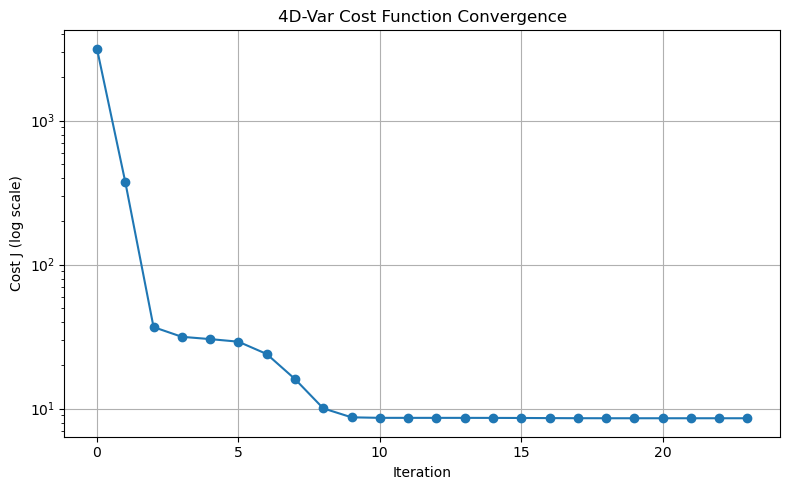

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/05_4dvar_cost_convergence.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(cost_history, marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J (log scale)")
ax.set_title("4D-Var Cost Function Convergence")
ax.grid(True)
fig.tight_layout()
fig_path = FIGURE_DIR / "05_4dvar_cost_convergence.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 8. 분석 궤적과 예측 비교

분석된 $\mathbf{x}_0$ 와 background $\mathbf{x}_0^b$ 에서 각각 모델을 **전체 구간**($t\in[0,2]$)으로 적분한다.

- window $[0,1]$: 관측을 사용한 분석 구간
- forecast $[1,2]$: 관측 없이 예측한 구간

4D-Var가 잘 작동하면, 분석 궤적이 window뿐 아니라 그 이후 예측에서도 truth에 가깝게 유지된다.

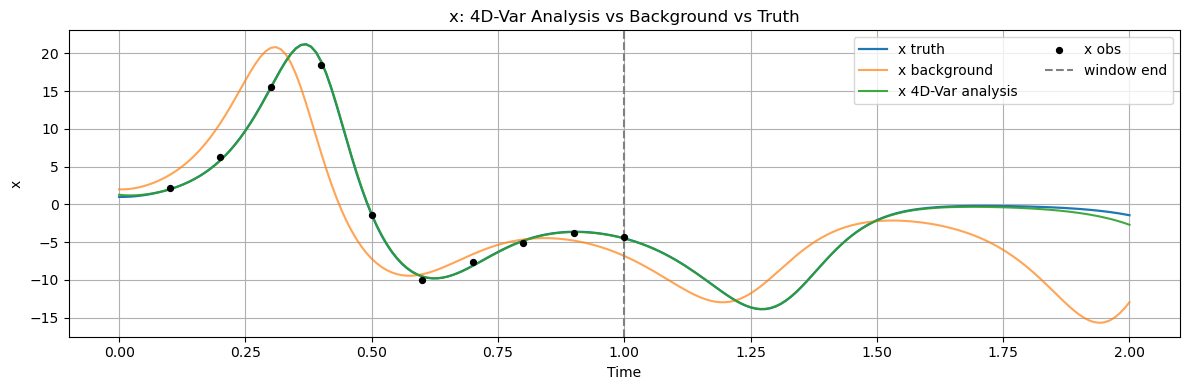

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/05_4dvar_x_trajectory.png


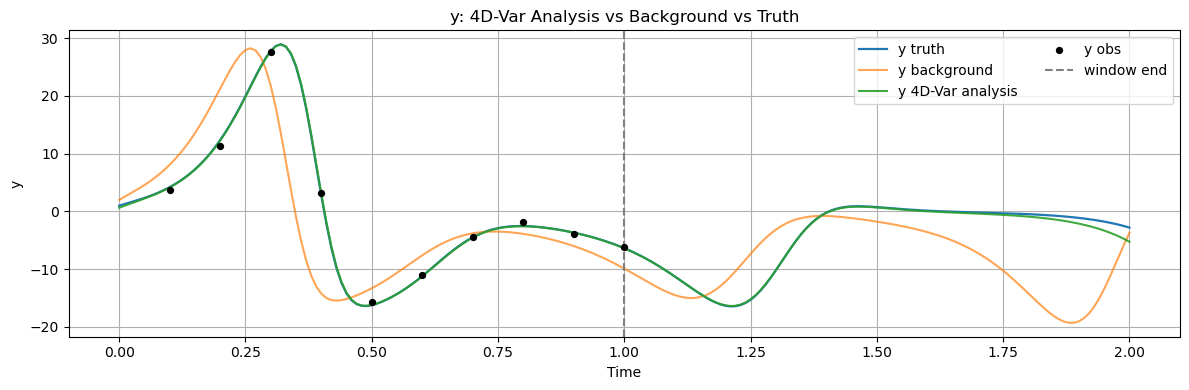

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/05_4dvar_y_trajectory.png


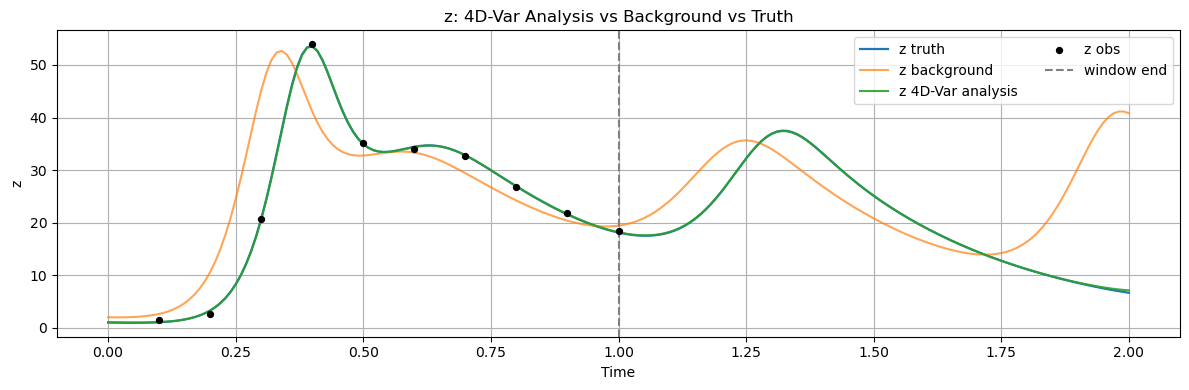

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/05_4dvar_z_trajectory.png


In [17]:
traj_analysis = integrate_euler(x0=x0_analysis, dt=dt, nsteps=nsteps_tot, rhs_func=lorenz63_rhs)
traj_background = integrate_euler(x0=x0_b, dt=dt, nsteps=nsteps_tot, rhs_func=lorenz63_rhs)

var_names = ["x", "y", "z"]
for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(time, truth[:, i], label=f"{name} truth", linewidth=1.6)
    ax.plot(time, traj_background[:, i], label=f"{name} background", alpha=0.7)
    ax.plot(time, traj_analysis[:, i], label=f"{name} 4D-Var analysis", alpha=0.9)
    ax.scatter(obs_times, observations[:, i], s=18, color="black", zorder=5,
               label=f"{name} obs")
    ax.axvline(time_win[-1], linestyle="--", color="gray", label="window end")

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"{name}: 4D-Var Analysis vs Background vs Truth")
    ax.legend(ncol=2)
    ax.grid(True)
    fig.tight_layout()
    fig_path = FIGURE_DIR / f"05_4dvar_{name}_trajectory.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved figure:", fig_path)

## 9. RMSE 비교

window 구간과 forecast 구간에서 background와 4D-Var analysis의 RMSE를 비교한다.

/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_47659/1483032788.py:13: UserWarning: Glyph 45149 (\N{HANGUL SYLLABLE GGEUT}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_47659/1483032788.py:15: UserWarning: Glyph 45149 (\N{HANGUL SYLLABLE GGEUT}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_path, dpi=150)


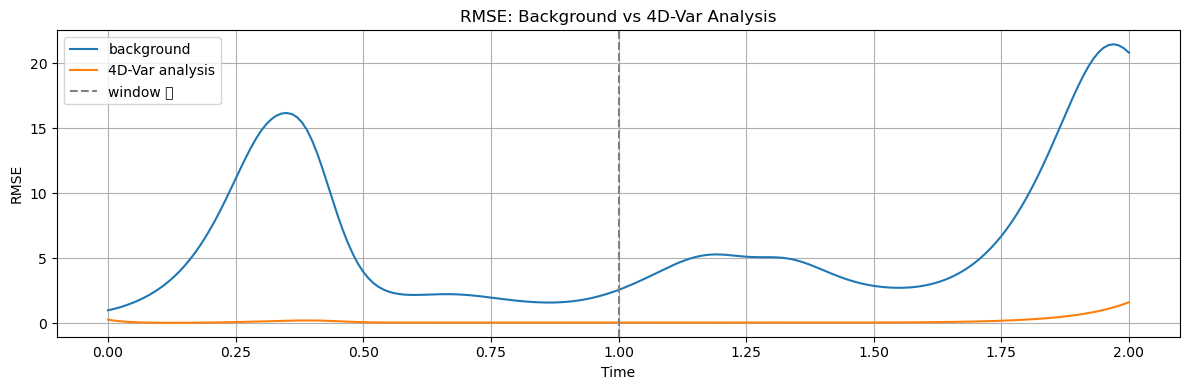

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/05_4dvar_rmse.png
Mean RMSE (window  )  background: 5.166525030004521 | analysis: 0.0840615816634367
Mean RMSE (forecast)  background: 7.032872246068135 | analysis: 0.21979421670361238


In [18]:
bg_rmse = rmse_time_series(traj_background, truth)
an_rmse = rmse_time_series(traj_analysis, truth)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, bg_rmse, label="background")
ax.plot(time, an_rmse, label="4D-Var analysis")
ax.axvline(time_win[-1], linestyle="--", color="gray", label="window 끝")
ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("RMSE: Background vs 4D-Var Analysis")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig_path = FIGURE_DIR / "05_4dvar_rmse.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

win_slice = slice(0, nsteps_win + 1)
fc_slice = slice(nsteps_win + 1, nsteps_tot + 1)
print("Mean RMSE (window  )  background:", mean_rmse(traj_background[win_slice], truth[win_slice]),
      "| analysis:", mean_rmse(traj_analysis[win_slice], truth[win_slice]))
print("Mean RMSE (forecast)  background:", mean_rmse(traj_background[fc_slice], truth[fc_slice]),
      "| analysis:", mean_rmse(traj_analysis[fc_slice], truth[fc_slice]))

## 10. 결과 저장

In [19]:
np.save(ASSIM_DIR / "05_4dvar_analysis_trajectory.npy", traj_analysis)
np.save(ASSIM_DIR / "05_4dvar_x0_analysis.npy", x0_analysis)

with open(ASSIM_DIR / "05_4dvar_summary.txt", "w", encoding="utf-8") as f:
    f.write("Lorenz-63 4D-Var 실습 요약\n\n")
    f.write(f"dt: {dt}\n")
    f.write(f"window steps: {nsteps_win}, total steps: {nsteps_tot}\n")
    f.write(f"obs_interval: {obs_interval}, obs_std: {obs_std}\n\n")
    f.write(f"x0_true     : {x0_true}\n")
    f.write(f"x0_b        : {x0_b} (err {np.linalg.norm(x0_b - x0_true):.4f})\n")
    f.write(f"x0_analysis : {x0_analysis} (err {np.linalg.norm(x0_analysis - x0_true):.4f})\n\n")
    f.write(f"window mean RMSE  background: {mean_rmse(traj_background[win_slice], truth[win_slice]):.6f}\n")
    f.write(f"window mean RMSE  analysis  : {mean_rmse(traj_analysis[win_slice], truth[win_slice]):.6f}\n")
    f.write(f"forecast mean RMSE background: {mean_rmse(traj_background[fc_slice], truth[fc_slice]):.6f}\n")
    f.write(f"forecast mean RMSE analysis  : {mean_rmse(traj_analysis[fc_slice], truth[fc_slice]):.6f}\n")

print("Saved 4D-Var results to:", ASSIM_DIR)

Saved 4D-Var results to: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation


## 11. 이번 실습 정리

이번 노트북에서는 Lorenz-63 모델에 strong-constraint 4D-Var를 적용했다.

확인한 내용은 다음과 같다.

1. 4D-Var는 시간창 전체의 관측을 한꺼번에 사용해 window 시작 상태 $\mathbf{x}_0$ 를 추정한다.
2. cost function의 gradient는 adjoint model로 효율적으로 계산하며, 유한차분과 정확히 일치했다.
3. `scipy.optimize`로 cost를 최소화하면 분석 초기조건이 truth에 가까워진다.
4. 분석된 $\mathbf{x}_0$ 는 window뿐 아니라 window 이후 예측의 정확도도 개선한다.

이번 실습의 핵심은 **adjoint가 gradient 계산을 가능하게 한다**는 점이다.
03번(TLM), 04번(adjoint)에서 만든 도구가 여기서 직접 쓰였다.

다음 실습(06)에서는 AI surrogate model을 학습해 수치모델을 대체/보정하는 가능성을 살펴본다.

In [20]:
print("다섯 번째 실습 완료")
print("다음 실습: 06_lorenz63_ai_surrogate.ipynb")

다섯 번째 실습 완료
다음 실습: 06_lorenz63_ai_surrogate.ipynb
